# Neural Networks Project: Assignment 2
## Image Recognition with Pre-trained MobileNetV2 (Fine-tuned)

This notebook contains the implementation of a Convolutional Neural Network (CNN) for image recognition using a pre-trained MobileNetV2 model that has been fine-tuned. There are some explanations and testing metrics for the model, but for a full comparison for the whole assignment, see report.pdf. 

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
import keras
from keras import layers, models
from keras.preprocessing import image_dataset_from_directory
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
from keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [39]:
DATA_DIR = "./data/centered"
original_dir = Path(DATA_DIR)
new_base_dir = Path("./data_split")

class_names = sorted(os.listdir(original_dir))
print(class_names)


['1', '2', '3', '4', '5']


In [40]:

IMG_SIZE = (224,224)
BATCH_SIZE = 16

train_ds = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 210 files belonging to 5 classes.
Found 45 files belonging to 5 classes.
Found 45 files belonging to 5 classes.


In [41]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05)
])

# MobileNetV2 Finetuned

First use feature extractor to train model head, then unfreeze the last layers of the base model and train the whole model with a lower learning rate. For the head training, the architecture consists of the MobileNetV2 model followed by a global average pooling layer and a dense layer with 128 neurons with ReLu as the activation function. Dropout was used for regularization before the output layer (with 5 neurons for the 5 classes). This matches the architecture of the frozen MobileNetV2 model, but here the head is trained only for 5 epochs.

The fine-tuning is done by unfreezing the last 30 layers of the base model and training the whole model for 50 epochs with early stopping with patience of 10 epochs. The learning rate is set to 1e-5, which is lower than the learning rate used for the head training. Different learning rates and amounts of unfrozen layers were tested, but the optimal results were achieved with these values. The test results are shown below.

In [42]:
base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = data_aug(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(5, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_4 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [43]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5


c:\Users\nealu\anaconda3\envs\keras\Lib\site-packages\jedi\inference\compiled\subprocess\functions.py:21: UserWarning: Module numpy._core.array not importable in path ['c:\\Users\\nealu\\anaconda3\\envs\\keras\\python311.zip', 'c:\\Users\\nealu\\anaconda3\\envs\\keras\\DLLs', 'c:\\Users\\nealu\\anaconda3\\envs\\keras\\Lib', 'c:\\Users\\nealu\\anaconda3\\envs\\keras', 'c:\\Users\\nealu\\anaconda3\\envs\\keras\\Lib\\site-packages'].
  return access.load_module(inference_state, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 38s 474ms/step - accuracy: 0.2381 - loss: 1.7572 - val_accuracy: 0.3111 - val_loss: 1.3561
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step - accuracy: 0.5333 - loss: 1.2403 - val_accuracy: 0.3778 - val_loss: 1.3317
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.5810 - loss: 1.0591 - val_accuracy: 0.4889 - val_loss: 1.2069
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 317ms/step - accuracy: 0.6333 - loss: 0.9382 - val_accuracy: 0.5111 - val_loss: 1.1288
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 334ms/step - accuracy: 0.6714 - loss: 0.8387 - val_accuracy: 0.4444 - val_loss: 1.1368


In [44]:
base_model.trainable = True

for layer in base_model.layers[:30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/50


14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 591ms/step - accuracy: 0.6810 - loss: 0.8049 - val_accuracy: 0.5111 - val_loss: 1.0390
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 494ms/step - accuracy: 0.7238 - loss: 0.6800 - val_accuracy: 0.6000 - val_loss: 0.9148
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 455ms/step - accuracy: 0.7571 - loss: 0.5962 - val_accuracy: 0.6667 - val_loss: 0.8819
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 463ms/step - accuracy: 0.7476 - loss: 0.5881 - val_accuracy: 0.5556 - val_loss: 0.9796
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 677ms/step - accuracy: 0.7619 - loss: 0.5604 - val_accuracy: 0.6889 - val_loss: 0.8196
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 565ms/step - accuracy: 0.8048 - loss: 0.5474 - val_accuracy: 0.6222 - val_loss: 0.8430
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 480ms/step - accuracy: 0.8048 - loss: 0.4770 - val_accuracy: 0.6889 - val_loss: 0.8018
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 949ms/step - accuracy: 0.8238 - loss: 0.4437 - val_accuracy: 0.7333 - va

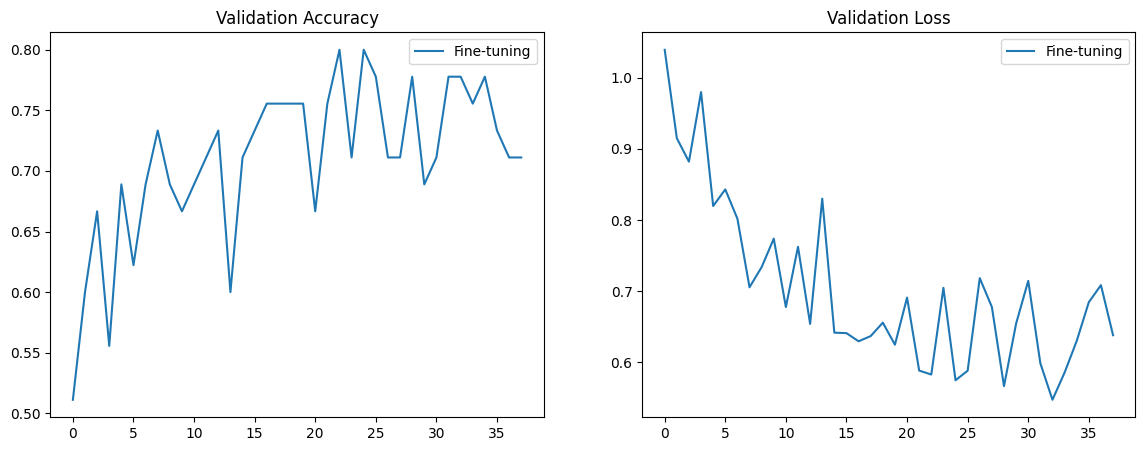

In [45]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(fine_history.history["val_accuracy"], label="Fine-tuning")
plt.title("Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(fine_history.history["val_loss"], label="Fine-tuning")
plt.title("Validation Loss")
plt.legend()

plt.show()


## Test Accuracy, Confusion Matrix and Mistaken Predictions


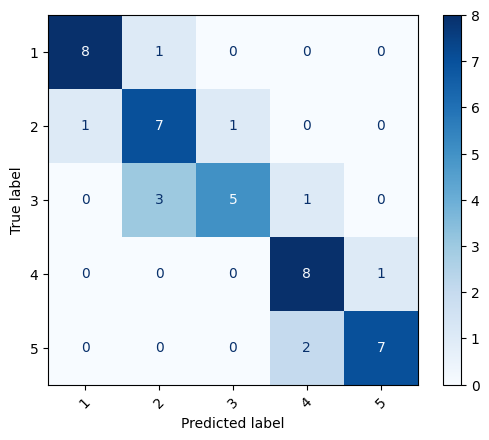

Test Accuracy: 0.7777777777777778


In [46]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

acc = np.mean(np.array(y_true) == np.array(y_pred))
print("Test Accuracy:", acc)


The test accuracy of the model is 0.78 which is better than the frozen MobileNetV2 model but in the same level as the baseline CNN model. The confusion matrix shows that the model struggles with the same classes as the baseline CNN model, which are the classes next to each other. Below are also the images that were mistaken by the model and as seen, this model also struggles with understanding the depth of the images, which results in mistakes between classes that are similar. However, the fine-tuned MobileNetV2 model seems to have less mistaken predictions than the frozen MobileNetV2 model, which indicates that fine-tuning has improved the performance of the model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


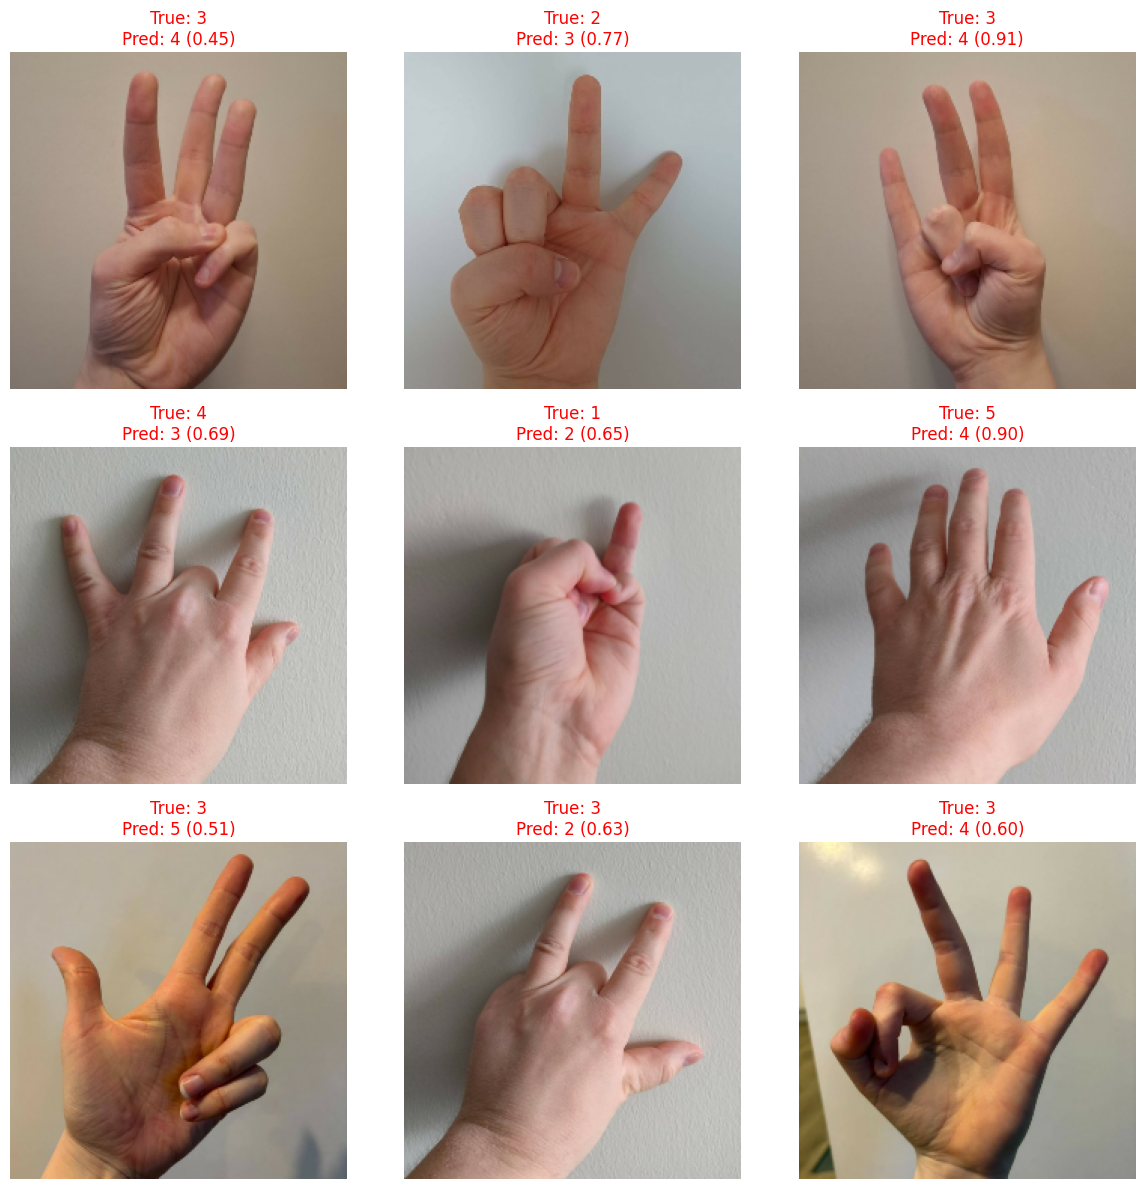

In [47]:
wrong_images = []
wrong_true = []
wrong_pred = []
wrong_probs = []

# collect wrong predictions
for images, labels in test_ds:
    preds = model.predict(images)

    for i in range(len(images)):
        pred_idx = np.argmax(preds[i])

        if pred_idx != labels[i]:
            wrong_images.append(images[i].numpy().astype("uint8"))
            wrong_true.append(class_names[labels[i]])
            wrong_pred.append(class_names[pred_idx])
            wrong_probs.append(preds[i])

# how many to show
N = min(9, len(wrong_images))

plt.figure(figsize=(12, 12))

for i in range(N):
    ax = plt.subplot(3, 3, i + 1)

    plt.imshow(wrong_images[i])
    plt.axis("off")

    confidence = np.max(wrong_probs[i])

    plt.title(
        f"True: {wrong_true[i]}\nPred: {wrong_pred[i]} ({confidence:.2f})",
        color="red"
    )

plt.tight_layout()
plt.show()